# Praktikum Scraping & EDA

Nama : Levina Zahrathul Huda
NRP  : 5054251033

Sumber data yang digunakan adalah website CompaniesMarketCap.com yang meyediakan informasi perusahaan berdasarkan market capitalization. Data yang ada terdiri dari 1500 perusahaan dengan 6 atribut, yaitu rank, nama_perusahaan, market_cap_usd_billion, harga_usd, perubahan_harian_persen, dan negara.

In [1]:
%pip install -q beautifulsoup4 requests pandas numpy matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
# LIBRARY

import requests
import pandas as pd
import numpy as np
import re
import time

from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [3]:
url = "https://companiesmarketcap.com/robots.txt"
response = requests.get(url)

print("Status:", response.status_code)
print(response.text)

Status: 200
User-agent: *
Disallow: /gotopage/
Disallow: /annual-reports/
Disallow: /annual-reports-10k/
Disallow: /annual-reports-20f/
Disallow: /quarterly-reports-10q/
Disallow: /financial-statements/
Disallow: /half-year-reports/
Disallow: /quarterly-reports/
Disallow: /financial-reports/
Disallow: /sustainability-reports/
Disallow: /esg-reports/
Disallow: /investor-presentations/

User-agent: AmazonAdBot
Allow: /



In [4]:
BASE_URL = "https://companiesmarketcap.com"
pages = [0] + list(range(2, 16))  # karena ada page yang overlap

print("Jumlah page:", len(pages))


Jumlah page: 15


In [5]:
# SCRAPING

def scrape_page(page):
    url = f"{BASE_URL}/page/{page}/"
    response = requests.get(url)
    soup = BeautifulSoup(response.text, "html.parser")
    table = soup.find("table")
    rows = table.find_all("tr")
    data = []

    for row in rows[1:]:
        cells = row.find_all("td")

        if len(cells) >= 6:
            data.append({
                "rank_raw": cells[1].get_text(strip=True),
                "nama_perusahaan_raw": cells[2].get_text(strip=True),
                "market_cap_raw": cells[3].get_text(strip=True),
                "harga_raw": cells[4].get_text(strip=True),
                "perubahan_harian_raw": cells[5].get_text(strip=True),
                "negara_raw": cells[-1].get_text(" ", strip=True),
            })

    return pd.DataFrame(data)

semua_data = []

for page in pages:
    print("Scraping page", page)
    data_page = scrape_page(page)
    print("Jumlah data:", len(data_page))
    semua_data.append(data_page)
    time.sleep(1)

df_raw = pd.concat(semua_data, ignore_index=True)

print("Jumlah data:", len(df_raw))

Scraping page 0
Jumlah data: 100
Scraping page 2
Jumlah data: 100
Scraping page 3
Jumlah data: 100
Scraping page 4
Jumlah data: 100
Scraping page 5
Jumlah data: 100
Scraping page 6
Jumlah data: 100
Scraping page 7
Jumlah data: 100
Scraping page 8
Jumlah data: 100
Scraping page 9
Jumlah data: 100
Scraping page 10
Jumlah data: 100
Scraping page 11
Jumlah data: 100
Scraping page 12
Jumlah data: 100
Scraping page 13
Jumlah data: 100
Scraping page 14
Jumlah data: 100
Scraping page 15
Jumlah data: 100
Jumlah data: 1500


In [6]:
# HASIL SCRAPING

print(df_raw.shape)

df_raw.head()

(1500, 6)


,rank_raw,nama_perusahaan_raw,market_cap_raw,harga_raw,perubahan_harian_raw,negara_raw
0,1,NVIDIANVDA,$5.271 T,$218.29,0.03%,🇺🇸 USA
1,2,AppleAAPL,$4.849 T,$332.27,1.75%,🇺🇸 USA
2,3,Alphabet (Google)GOOG,$4.102 T,$335.45,1.53%,🇺🇸 USA
3,4,MicrosoftMSFT,$3.680 T,$495.63,0.65%,🇺🇸 USA
4,5,AmazonAMZN,$2.769 T,$256.78,1.94%,🇺🇸 USA


In [7]:
from pathlib import Path

Path("data").mkdir(exist_ok=True)
df_raw.to_csv("data/companies_marketcap_raw.csv", index=False)

print("Data successfully saved.")

Data successfully saved.


In [8]:
df = pd.read_csv("data/companies_marketcap_raw.csv")

print("Shape:", df.shape)

df.head()

Shape: (1500, 6)


,rank_raw,nama_perusahaan_raw,market_cap_raw,harga_raw,perubahan_harian_raw,negara_raw
0,1,NVIDIANVDA,$5.271 T,$218.29,0.03%,🇺🇸 USA
1,2,AppleAAPL,$4.849 T,$332.27,1.75%,🇺🇸 USA
2,3,Alphabet (Google)GOOG,$4.102 T,$335.45,1.53%,🇺🇸 USA
3,4,MicrosoftMSFT,$3.680 T,$495.63,0.65%,🇺🇸 USA
4,5,AmazonAMZN,$2.769 T,$256.78,1.94%,🇺🇸 USA


In [9]:
# INFORMASI DATASET

df.info()

print("Shape:", df.shape)
print("Tipe data:")
print(df.dtypes)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   rank_raw              1500 non-null   int64 
 1   nama_perusahaan_raw   1500 non-null   object
 2   market_cap_raw        1500 non-null   object
 3   harga_raw             1500 non-null   object
 4   perubahan_harian_raw  1500 non-null   object
 5   negara_raw            1500 non-null   object
dtypes: int64(1), object(5)
memory usage: 70.4+ KB
Shape: (1500, 6)
Tipe data:
rank_raw                 int64
nama_perusahaan_raw     object
market_cap_raw          object
harga_raw               object
perubahan_harian_raw    object
negara_raw              object
dtype: object


In [10]:
# CLEANING DATA
# ubah string jadi angka

def ubah_market_cap(x):
    x = x.replace("$", "").strip()
    angka, satuan = x.split()
    angka = float(angka)

    if satuan == "T":
        angka = angka*1000

    elif satuan == "B":
        angka = angka

    elif satuan == "M":
        angka = angka/1000

    return angka


def ubah_angka(x):
    x = x.replace("$", "")
    x = x.replace("%", "")
    x = x.replace(",", "")

    return float(x)

def negara(x):
    return " ".join(x.split()[1:])


df["rank"] = df["rank_raw"].astype(int)
df["nama_perusahaan"] = df["nama_perusahaan_raw"]
df["market_cap_usd_billion"] = df["market_cap_raw"].apply(ubah_market_cap)
df["harga_usd"] = df["harga_raw"].apply(ubah_angka)
df["perubahan_harian_persen"] = df["perubahan_harian_raw"].apply(ubah_angka)
df["negara"] = df["negara_raw"].apply(negara)

df = df[
    [
        "rank",
        "nama_perusahaan",
        "market_cap_usd_billion",
        "harga_usd",
        "perubahan_harian_persen",
        "negara"
    ]
]

print(df.shape)
df.head()

(1500, 6)


,rank,nama_perusahaan,market_cap_usd_billion,harga_usd,perubahan_harian_persen,negara
0,1,NVIDIANVDA,5271.0,218.29,0.03,USA
1,2,AppleAAPL,4849.0,332.27,1.75,USA
2,3,Alphabet (Google)GOOG,4102.0,335.45,1.53,USA
3,4,MicrosoftMSFT,3680.0,495.63,0.65,USA
4,5,AmazonAMZN,2769.0,256.78,1.94,USA


# Tipe Atribut

| Atribut                   |      Tipe       |
| ------------------------- | --------------- |
|  rank                     | Numerik diskrit |
|  nama_perusahaan          | Nominal         |
|  market_cap_usd_billion   | Numerik kontinu |
|  harga_usd                | Numerik kontinu |
|  perubahan_harian_persen  | Numerik kontinu |
|  negara                   | Nominal         |


Identifikasi Tipe Atribut
- rank: Numerik diskrit dan bersifat ordinal karena menunjukkan urutan peringkat perusahaan.
- nama_perusahaan: Nominal karena digunakan untuk identitas perusahaan.
- market_cap_usd_billion: Numerik kontinu karena berupa nilai market cap.
- harga_usd: Numerik kontinu karena berupa nilai harga saham.
- perubahan_harian_persen: Numerik kontinu karena menunjukkan persentasi perubahan harga harian.
- negara: Nominal karena menunjukkan kategori negara asal perusahaan.

# Statistik Deskriptif Numerik


In [11]:
angka = [
    "rank",
    "market_cap_usd_billion",
    "harga_usd",
    "perubahan_harian_persen"
]

statistik = df[angka].describe().T
statistik["median"] = df[angka].median()
statistik["mode"] = df[angka].mode().iloc[0]
statistik = statistik[["mean", "median", "mode", "std", "min", "max"]]

statistik


,mean,median,mode,std,min,max
rank,750.500000,750.500,1.00,433.157015,1.00,1500.00
market_cap_usd_billion,86.218727,33.910,17.69,282.767109,14.94,5271.00
harga_usd,158.159907,57.985,0.65,419.811100,0.16,10304.00
perubahan_harian_persen,1.265980,0.820,0.00,1.390127,0.00,12.44


In [12]:
# FREKUENSI NEGARA

print(df["negara"].value_counts().head(15))
print("Jumlah negara:", df["negara"].nunique())

negara
USA            528
China          154
Japan          104
India           64
Canada          57
UK              51
Germany         42
Switzerland     38
Taiwan          37
S. Korea        35
France          33
Australia       26
Hong Kong       25
Netherlands     22
Sweden          22
Name: count, dtype: int64
Jumlah negara: 50


In [13]:
# MISSING VALUE

print(df.isna().sum())


# DATA DUPLIKAT

print("\nDuplikat seluruh baris:", df.duplicated().sum())
print("Duplikat rank:", df["rank"].duplicated().sum())
print("Duplikat nama perusahaan:", df["nama_perusahaan"].duplicated().sum())


# OUTLIER
# OUTLIER MARKET CAP

Q1 = df["market_cap_usd_billion"].quantile(0.25)
Q3 = df["market_cap_usd_billion"].quantile(0.75)

IQR = Q3-Q1

batas_bawah = Q1-1.5*IQR
batas_atas = Q3+1.5*IQR

outlier = df[
    (df["market_cap_usd_billion"] < batas_bawah) |
    (df["market_cap_usd_billion"] > batas_atas)
]

print("\nJumlah outlier market cap:", len(outlier))


# OUTLIER HARGA

Q1 = df["harga_usd"].quantile(0.25)
Q3 = df["harga_usd"].quantile(0.75)

IQR = Q3-Q1

batas_bawah = Q1-1.5*IQR
batas_atas = Q3+1.5*IQR

outlier = df[
    (df["harga_usd"] < batas_bawah) |
    (df["harga_usd"] > batas_atas)
]

print("Jumlah outlier harga:", len(outlier))


# OUTLIER PERUBAHAN HARIAN

Q1 = df["perubahan_harian_persen"].quantile(0.25)
Q3 = df["perubahan_harian_persen"].quantile(0.75)

IQR = Q3-Q1

batas_bawah = Q1-1.5*IQR
batas_atas = Q3+1.5*IQR

outlier = df[
    (df["perubahan_harian_persen"] < batas_bawah) |
    (df["perubahan_harian_persen"] > batas_atas)
]

print("Jumlah outlier perubahan harian:", len(outlier))


outlier[
    [
        "rank",
        "nama_perusahaan",
        "market_cap_usd_billion",
        "negara"
    ]
].head(10)


rank                       0
nama_perusahaan            0
market_cap_usd_billion     0
harga_usd                  0
perubahan_harian_persen    0
negara                     0
dtype: int64

Duplikat seluruh baris: 0
Duplikat rank: 0
Duplikat nama perusahaan: 0

Jumlah outlier market cap: 165
Jumlah outlier harga: 121
Jumlah outlier perubahan harian: 90


,rank,nama_perusahaan,market_cap_usd_billion,negara
16,17,SK Hynix000660.KS,904.15,S. Korea
28,29,CiscoCSCO,442.08,USA
40,41,DellDELL,360.69,USA
55,56,Arm HoldingsARM,282.79,UK
64,65,Arista NetworksANET,251.72,USA
66,67,Texas InstrumentsTXN,245.38,USA
80,81,IBMIBM,229.21,USA
87,88,SoftBank Group Corp.9984.T,215.53,Japan
89,90,Marvell TechnologyMRVL,212.18,USA
92,93,AmphenolAPH,206.94,USA


# Penanganan Outlier
Outlier ditemukan pada market_cap_usd_billion, harga_usd, dan perubahan_harian_persen. Outlier tidak dihapus karena nilai tersebut merupakan data yang valid dan dapat merepresentasikan kondisi perusahaan yang mempunyai market cap atau harga saham yang lebih tinggi dibandingkan perusahaan lainnya. Oleh karena itu, outlier dipertahankan untuk analisis lebih lanjut.

# Visualisasi Data

# HISTOGRAM MARKET CAP

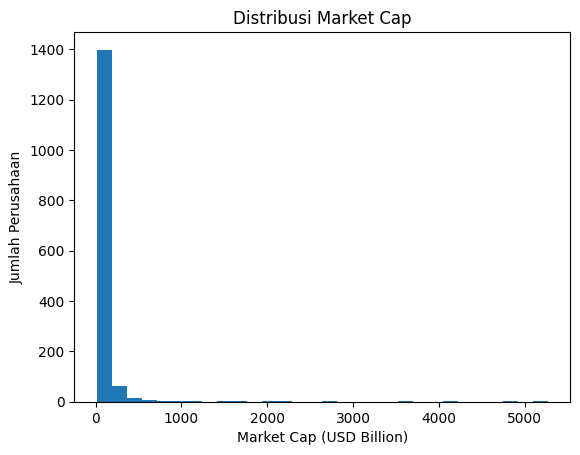

In [14]:

plt.hist(df["market_cap_usd_billion"], bins=30)
plt.xlabel("Market Cap (USD Billion)")
plt.ylabel("Jumlah Perusahaan")
plt.title("Distribusi Market Cap")
plt.show()

Sebagian besar perusahaan memiliki market cap yang relatif kecil, sedangkan hanya sedikit perusahaan yang memiliki market cap yang sangat besar. Hal ini menunjukkan adanya beberapa perusahaan dengan nilai market cap yang jauh lebih tinggi dibandingkan perusahaan lainnya.

# HISTOGRAM PERUBAHAN HARIAN


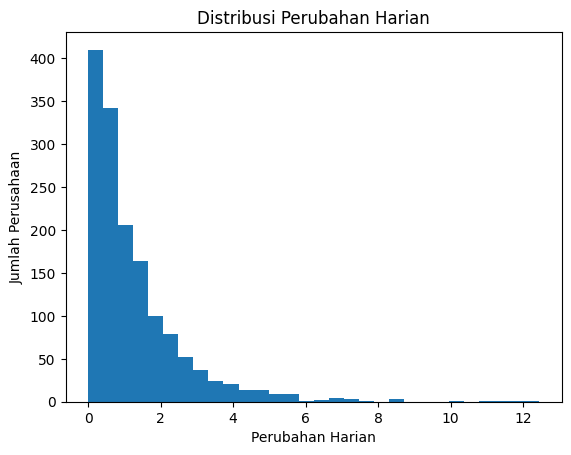

In [15]:
plt.hist(df["perubahan_harian_persen"], bins=30)
plt.xlabel("Perubahan Harian")
plt.ylabel("Jumlah Perusahaan")
plt.title("Distribusi Perubahan Harian")
plt.show()

Sebagian besar perusahaan memiliki perubahan harga harian yang relatif kecil, sedangkan hanya sebagian kecil perusahaan yang memiliki perubahan harga yang lebih besar. Distribusi data cenderung memusat pada persentase perubahan yang rendah.

# BAR CHART NEGARA


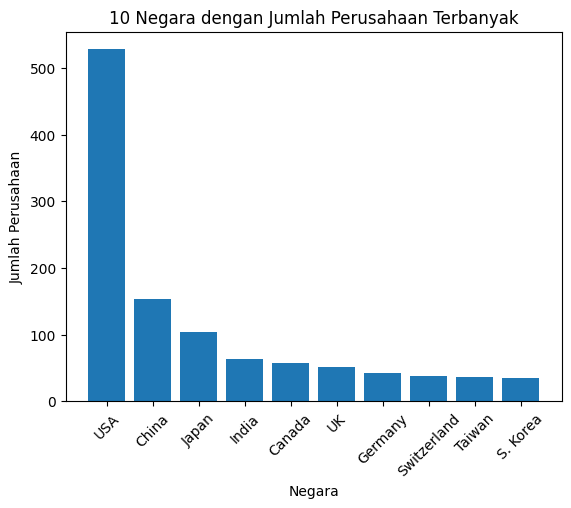

In [16]:

negara = df["negara"].value_counts().head(10)

plt.bar(negara.index, negara.values)
plt.xlabel("Negara")
plt.ylabel("Jumlah Perusahaan")
plt.title("10 Negara dengan Jumlah Perusahaan Terbanyak")
plt.xticks(rotation=45)
plt.show()

Grafik menunjukkan bahwa jumlah perusahaan dalam dataset tidak tersebar secara merata pada setiap negara. Beberapa negara memiliki jumlah perusahaan yang jauh lebih banyak dibandingkan negara lainnya. USA memiliki jumlah perusahaan terbanyak dalam dataset dibandingkan negara lainnya.

# SCATTER PLOT MARKET CAP & HARGA


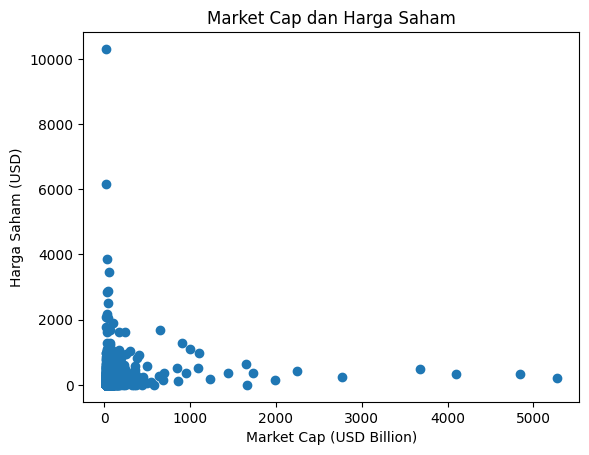

In [17]:

plt.scatter(df["market_cap_usd_billion"], df["harga_usd"])
plt.xlabel("Market Cap (USD Billion)")
plt.ylabel("Harga Saham (USD)")
plt.title("Market Cap dan Harga Saham")
plt.show()

 Scatter plot menunjukkan bahwa adanya pola hubungan positif antara market cap dan harga saham, tetapi sangat lemah. Terlihat dari titik-titik data yang cukup menyebar dan tidak membentuk pola yang jelas. Nilai korelasi sebesar 0,072 menunjukkan bahwa hubungan antara kedua variabel ini sangat lemah.

# CORRELATION HEATMAP


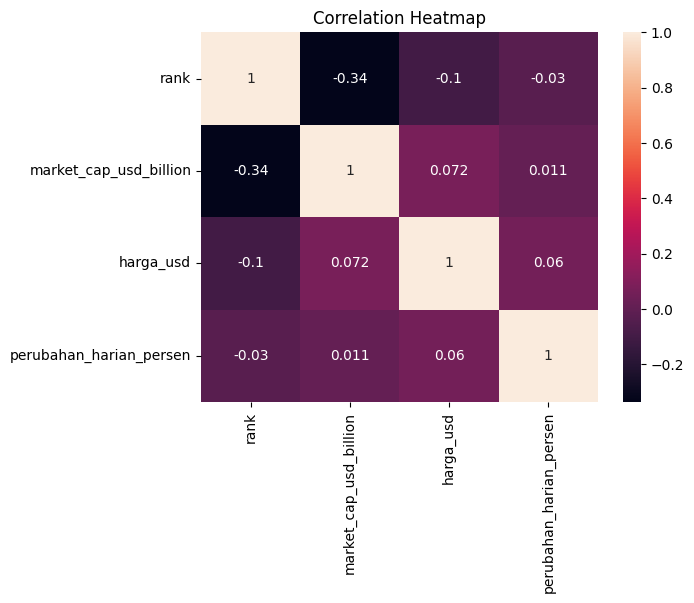

In [18]:

angka = [
    "rank",
    "market_cap_usd_billion",
    "harga_usd",
    "perubahan_harian_persen"
]

correlation = df[angka].corr()

sns.heatmap(correlation, annot=True)
plt.title("Correlation Heatmap")
plt.show()

Sebagian besar variabel memiliki korelasi yang sangat lemah atau mendekati nol. Korelasi yang paling terlihat terdapat pada rank dan market_cap_usd_billion sebesar -0.34, yang menunjukkan bahwa semakin besar nilai rank, market cap perusahaan cenderung semakin kecil. Sementara itu, hubungan antara market cap, harga saham, dan perubahan harian cenderung sangat lemah. Hal ini menunjukkan bahwa variabel-variabel tersebut tidak memiliki hubungan linear yang kuat.

In [19]:
df.to_csv("data/companies_marketcap_1500.csv", index=False)

print("Dataset final successfully saved.")

Dataset final successfully saved.
